<a href="https://colab.research.google.com/github/sitaramnbist/microPython-on-unicorn/blob/main/XOR_emlearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
pip install emlearn

In [8]:
import os.path

import emlearn
import numpy
import pandas
import seaborn
import matplotlib.pyplot as plt

try:
    # When executed as regular .py script
    here = os.path.dirname(__file__)
except NameError:
    # When executed as Jupyter notebook / Sphinx Gallery
    here = os.getcwd()

         0    1  label
split                 
val    126  -35   True
val    165  388  False
val    -59  -59  False
train  402  195  False
train -119  138   True


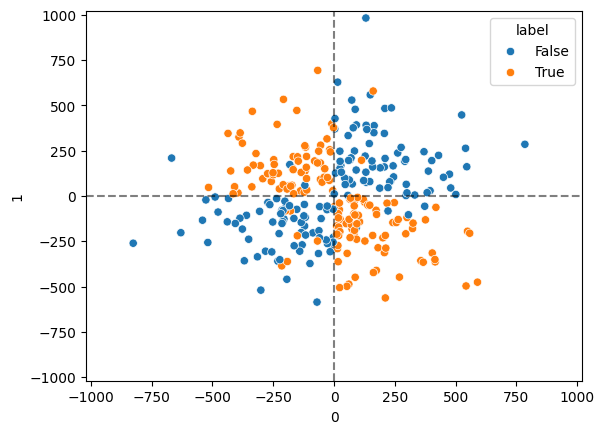

In [9]:
def make_noisy_xor(seed=42):
    xx, yy = numpy.meshgrid(numpy.linspace(-3, 3, 500),
                         numpy.linspace(-3, 3, 500))

    rng = numpy.random.RandomState(seed)
    X = rng.randn(300, 2)
    y = numpy.logical_xor(X[:, 0] > 0, X[:, 1] > 0)

    # Add some noise
    flip = rng.randint(300, size=15)
    y[flip] = ~y[flip]

    df = pandas.DataFrame((X * 255).astype(numpy.int16))
    df['label'] = y

    return df

def dataset_split_random(data, val_size=0.25, test_size=0.25, random_state=3, column='split'):
    """
    Split DataFrame into 3 non-overlapping parts: train,val,test with specified proportions

    Returns a new DataFrame with the rows marked by the assigned split in @column
    """
    train_size = (1.0 - val_size - test_size)
    from sklearn.model_selection import train_test_split

    train_val_idx, test_idx = train_test_split(data.index, test_size=test_size, random_state=random_state)
    val_ratio = (val_size / (val_size+train_size))
    train_idx, val_idx = train_test_split(train_val_idx, test_size=val_ratio, random_state=random_state)

    data = data.copy()
    data.loc[train_idx, column] = 'train'
    data.loc[val_idx, column] = 'val'
    data.loc[test_idx, column] = 'test'
    return data

dataset = make_noisy_xor()
dataset = dataset_split_random(dataset, test_size=0.10).set_index('split')

# Plot the dataset
ax = seaborn.scatterplot(data=dataset, x=0, y=1, hue='label')
ax.axvline(0.0, ls='--', alpha=0.5, color='black')
ax.axhline(0.0, ls='--', alpha=0.5, color='black')
ax.set_xlim(-4.0*255, +4.0*255)
ax.set_ylim(-4.0*255, +4.0*255)

# Show colums of the data
print(dataset.head(5))

In [10]:
def train_model(dataset, seed=42):
    from sklearn.ensemble import RandomForestClassifier

    #feature_columns =
    X_train = dataset.loc['train', [0, 1]]
    Y_train = dataset.loc['train', 'label']

    model = RandomForestClassifier(n_estimators=10, max_depth=5, random_state=seed)
    model.fit(X_train, Y_train)

    return model


model = train_model(dataset)

In [11]:
def convert_model(model):

    model_filename = os.path.join(here, 'xor_model.h')
    cmodel = emlearn.convert(model)
    code = cmodel.save(file=model_filename, name='xor')

    assert os.path.exists(model_filename)
    print(f"Generated {model_filename}")

convert_model(model)

Generated /content/xor_model.h


In [21]:
void setup() {
  Serial.begin(115200);
  randomSeed(analogRead(0));
}

void loop() {
  int x = random(-600, 601);
  int y = random(-600, 601);

  // XOR logic: one positive and one non-positive
  int prediction = ((x > 0) != (y > 0));

  Serial.print("X=");
  Serial.print(x);

  Serial.print(" Y=");
  Serial.print(y);

  Serial.print(" Class=");
  Serial.println(prediction);

  delay(1000);
}

SyntaxError: invalid syntax (1577126903.py, line 1)